# Método de bisección

La busqueda de raices consiste en obtener una raiz o solución de una ecuación de la forma $f(x) = 0$ para una función dada $f$. 

Supongamos que $f$ es una función continua definida en el intervalo $[a,b]$ con $f(a)$ y $f(b)$ de signos diferentes. Por el teorema del valor intermedio sabemos que debe haber un valor p para el cuál $f(p) = 0$. El método requiere dividir varias veces a la mitad los subintervalos de $[a,b]$ y en cada paso localizar la mitad que contenga a p.

Supongamos que $a_1 = a, b_1 = b$ y $p_1$ el punto medio del intervalo. 

$$p_1 = a_1 + \frac{b_1 - a_1}{2} = \frac{a_1 + b_1}{2}$$

La condición de parada es cuando $\frac{b-a}{2} < \epsilon$ que nos da cota conservadora del error.

<center>

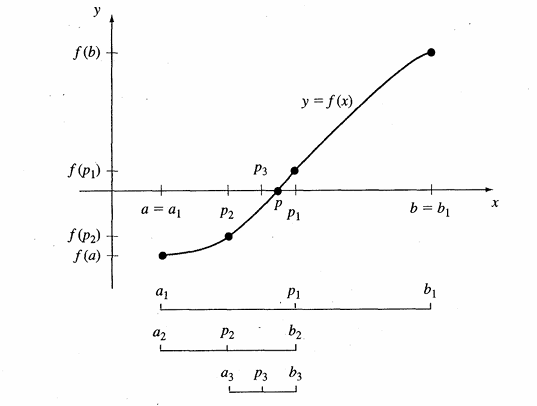

<center>



n  a_n            b_n            c_n            f(c)           error          
1  1.0000000000   2.0000000000   1.5000000000   0.2500000000   5.000000e-01   
2  1.0000000000   1.5000000000   1.2500000000   -0.4375000000  2.500000e-01   
3  1.2500000000   1.5000000000   1.3750000000   -0.1093750000  1.250000e-01   
4  1.3750000000   1.5000000000   1.4375000000   0.0664062500   6.250000e-02   
5  1.3750000000   1.4375000000   1.4062500000   -0.0224609375  3.125000e-02   
6  1.4062500000   1.4375000000   1.4218750000   0.0217285156   1.562500e-02   
7  1.4062500000   1.4218750000   1.4140625000   -0.0004272461  7.812500e-03   
8  1.4140625000   1.4218750000   1.4179687500   0.0106353760   3.906250e-03   
9  1.4140625000   1.4179687500   1.4160156250   0.0051002502   1.953125e-03   
10 1.4140625000   1.4160156250   1.4150390625   0.0023355484   9.765625e-04   
11 1.4140625000   1.4150390625   1.4145507812   0.0009539127   4.882812e-04   
12 1.4140625000   1.4145507812   1.4143066406   0.00

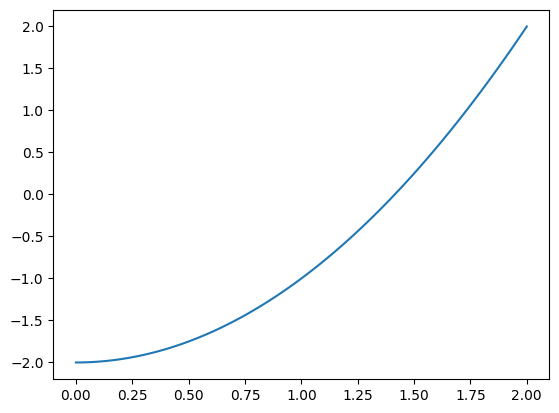

In [72]:
# Implementación del método de bisección
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return x**2 - 2 # Función igualada a cero 

def biseccion(f, a, b, N, tol):

    if np.sign(f(a))*np.sign(f(b)) > 0:
        print('No hay una raiz en este intervalo')
    
    print(f"{'n':<{3}}{'a_n':<{15}}{'b_n':<{15}}{'c_n':<{15}}{'f(c)':<{15}}{'error':<{15}}")

    for i in range(N):


        c = (a+b)/2
        y = f(c)
        error = abs((b-a)/2)

        print(f"{i+1:<{3}}{a:<{15}.10f}{b:<{15}.10f}{c:<{15}.10f}{y:<{15}.10f}{error:<{15}e}")

        # Decimos que si el intervalo donde se encuentra la raiz es menor que la tolerancia, paramos
        # Este método de parada es bastante conservador puesto que el error podría ser aún menor

        if error < tol: 
            return c, error
        
        if y == 0.:
            return c, error
        
        if np.sign(f(a))*np.sign(y) < 0:
            b = c
        else:
            a = c
    
    print('No se pudo obtener la raiz con la aproximación deseada')
    return c, error
    
raiz, error = biseccion(f,1,2,25,1e-6)    
print(f'\nLa raiz aproximada es de {raiz} con un error de {error:e}')


x = np.linspace(0,2,100)
plt.plot(x, f(x))
plt.show()



    

    



# Iteración de punto fijo

Un punto fijo de una función g es un número para el cual $g(r) = r$. Los problemas de busqueda de raices y punto fijo son equivalentes.

Pensemos en la ecuación $cos(x) - x = 0$, la ecuación de punto fijos $cos(x) = x$ es el mismo problema desde un punto de vista distinto. Si la salida es igual a la entrada ese número entonces es un punto fijo de $cos(x)$ y a su vez es solución de $cos(x) - x = 0$

Primero se lleva la ecuación a la forma $g(x) = x$, posterior procede la iteración de punto fijo, empezando con una estimación inicial $x_0$, para luego iterar $g$.


n  x0             f(x0)          error     
1  0.0000000000   1.0000000000   1.000000e+00
2  1.0000000000   0.6988313211   3.011687e-01
3  0.6988313211   0.8211024770   1.222712e-01
4  0.8211024770   0.7706196800   5.048280e-02
5  0.7706196800   0.7915188509   2.089917e-02
6  0.7915188509   0.7828629457   8.655905e-03
7  0.7828629457   0.7864482811   3.585335e-03
8  0.7864482811   0.7849631907   1.485090e-03
9  0.7849631907   0.7855783350   6.151443e-04
10 0.7855783350   0.7853235339   2.548011e-04
11 0.7853235339   0.7854290760   1.055421e-04
12 0.7854290760   0.7853853590   4.371696e-05
13 0.7853853590   0.7854034672   1.810816e-05
14 0.7854034672   0.7853959665   7.500644e-06
15 0.7853959665   0.7853990734   3.106868e-06
16 0.7853990734   0.7853977865   1.286907e-06
17 0.7853977865   0.7853983195   5.330543e-07
18 0.7853983195   0.7853980987   2.207983e-07
La solución aproximada es de 0.7853980987271117 con un error de 2.207983403890168e-07


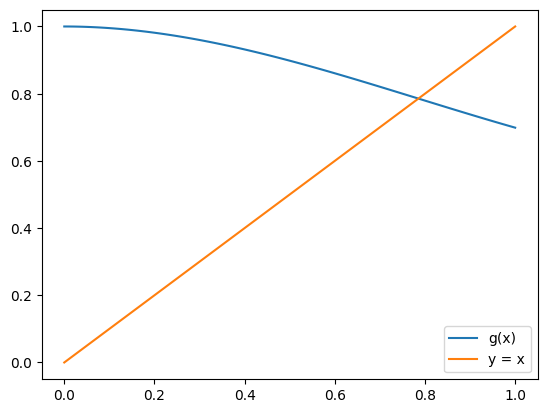

In [88]:
# Implementación de punto fijo
import matplotlib.pyplot as plt
import numpy as np

# Para la ecuación cos(x) = sin(x)

def g(x):
    return x + np.cos(x) - np.sin(x)

def dg(x):
    return 1 - np.sin(x) - np.cos(x)


def punto_fijo(g, x0, N, tol, dg):

    if abs(dg(x0)) >= 1:
        print('La iteración no converge')
        return None, None

    print(f"{'n':<{3}}{'x0':<{15}}{'f(x0)':<{15}}{'error':<{10}}")

    for i in range(N):
        x = g(x0)

        error = abs(x - x0)

        print(f"{i+1:<{3}}{x0:<{15}.10f}{x:<{15}.10f}{error:<{10}e}")

        if error < tol:
            return x, error
        
        x0 = x

    print('No se pudo obtener la raiz con la aproximación deseada')
    return x, error

x, error = punto_fijo(g, 0., 100, 0.5e-6, dg)
print(f'La solución aproximada es de {x} con un error de {error}')
x = np.linspace(0,1,100)
plt.plot(x, g(x), label = 'g(x)')
plt.plot(x, x, label = 'y = x')
plt.legend()
plt.show()



    

# Error hacia adelante y error hacia atrás

Usa el método de bisección para encontrar la raiz de $f(x) = x^3 -2x^2 + \frac{4}{3}x - \frac{8}{27}$ hasta seis cifras significativas correctas

n  a_n            b_n            c_n            f(c)           error          
1  0.5000000000   1.0000000000   0.7500000000   0.0005787037   2.500000e-01   
2  0.5000000000   0.7500000000   0.6250000000   -0.0000723380  1.250000e-01   
3  0.6250000000   0.7500000000   0.6875000000   0.0000090422   6.250000e-02   
4  0.6250000000   0.6875000000   0.6562500000   -0.0000011303  3.125000e-02   
5  0.6562500000   0.6875000000   0.6718750000   0.0000001413   1.562500e-02   
6  0.6562500000   0.6718750000   0.6640625000   -0.0000000177  7.812500e-03   
7  0.6640625000   0.6718750000   0.6679687500   0.0000000022   3.906250e-03   
8  0.6640625000   0.6679687500   0.6660156250   -0.0000000003  1.953125e-03   
9  0.6660156250   0.6679687500   0.6669921875   0.0000000000   9.765625e-04   
10 0.6660156250   0.6669921875   0.6665039062   -0.0000000000  4.882812e-04   
11 0.6665039062   0.6669921875   0.6667480469   0.0000000000   2.441406e-04   
12 0.6665039062   0.6667480469   0.6666259766   -0.0

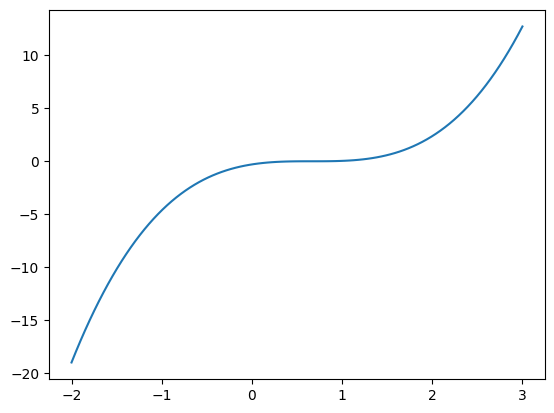

In [73]:
def f(x):
    return x**3 - 2*x**2 + (4/3)*x - (8/27)

raiz, error = biseccion(f, 0.5, 1, 100, 0.5e-6)


x = np.linspace(-2,3,100)
plt.plot(x,f(x))
plt.show()

Como se podrá notar no es posible, alcanzar la raiz con la precisión deseada, esto debido a que el error hacia atrás de nuestro problema se encuentra en el orden del $\epsilon_{maq}$. Como puede verse llegado a la iteración 16 en el ejemplo anterior el valor de $ f(x_a) $ es cero. Debajo de  $\epsilon_{maq}$ no es posible calcular un valor de doble precisión de manera confiable. Si el error hacia atrás no puede disminuirse tampoco el error hacia adelante.

<center>

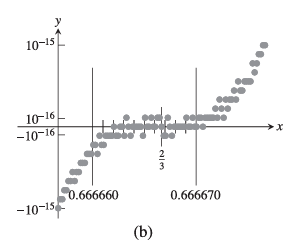

<center>

El **error hacia atrás** se define como el error debido a los datos que definen el problema, en este caso la ecuación a utilizar por lo tanto el error hacia atrás es $\lvert f(x_a) \rvert$ donde $x_a$ es la aproximación encontrada al valor real de la raiz. El **error hacia adelante** es el error sobre la solución, si se conoce la solución real (r), este error se define como $\lvert r - x_a \rvert $.

# Sensibilidad de la localización de raices

Un problema se denomina sensible si los pequeños errores en la entrada, en este caso la ecuación a resolver, dan lugar a grandes errores en la salida o solución. 

Para entender la magnificación del error se presenta la siguiente fórmula para predecir cuán lejos se mueve una raíz cuando la ecuación cambia. Supongamos que el problema es encontrar una raiz de $f(x) = 0$ pero que se hace un cambio pequeño a la entrada $\epsilon g(x) $ donde $\epsilon$ es pequeño. Sea $\Delta r $ el cambio en la raiz:

$$ f(r + \Delta r) + \epsilon g(r + \Delta r) = 0$$
La expansión de Taylor de grado 1 es:
$$ f(r) + (\Delta r)f'(r) + \epsilon g(r) + \epsilon (\Delta r) g'(r) + O((\Delta r)^2) = 0$$

$$(\Delta r)(f'(r) + \epsilon g'(r)) \approx -f(r) - \epsilon g(r) = - \epsilon g(r) $$

La sensibilidad entonces es: 

$$ \Delta r \approx \frac{-\epsilon g(r)}{f'(r) + \epsilon g'(r)} \approx -\epsilon \frac{g(r)}{f'(r)}$$

Donde $\epsilon$ es pequeña en comparación de $f'(r)$ y $f'(r) \neq 0$

Ejemplo:

Se tiene el polinomio $P(x) = (x-1)(x-2)(x-3)(x-4)(x-5)(x-6)-10^{-6}x^7$, siendo $\epsilon(x) = -10^{-6}x^7$, la mayor raiz es 6. Hasta dónde se traslada la raiz al agregar ese término extra?

$$\Delta r \approx -\frac{\epsilon 6^7}{5!} = -2332.8 \epsilon$$

En otras palabras un error de orden $10^{-6}$ en la entrada se convierte en uno de ${10^{-3}}$ en la salida

El factor en que se magnifica el error se puede calcular como:

$$ factor\,\, de\,\, magnificancia\,\, del\,\, error = \frac{error\,\, relativo\,\, hacia\,\, delante}{error\,\, relativo\,\, hacia\,\, atrás} $$

$$ factor\,\, de\,\, magnificancia\,\, del\,\, error =  \lvert \frac{\Delta r/r}{\epsilon g(r)/g(r)} \rvert = \lvert \frac{g(r)}{rf'(r)} \rvert$$

Para el ejemplo anterior:

$$ factor = \frac{6^7}{5!(6)} = 388.8$$

# Método de Newton-Raphson

Este método converge mucho más rápido que los métodos anteriores. Para encontrar $f(x) = 0$ se da una estimación inicial $x_0$ y se traza la recta tangente a la función en $x_0$. La recta tangente seguirá a la función hasta el eje x hacia la raiz. La intersección de la recta de la pendiente con el eje x es una raiz aproximada. Este paso es iterable.

<center>

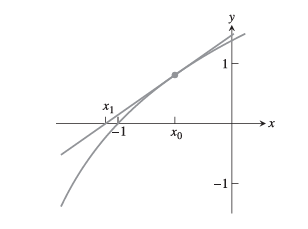

<center>





Para formar la recta nos auxiliamos de la ecuación punto pendiente de la recta.
La pendientes es $f'(x)$, un punto de la recta es $(x_0, f(x_0))$. Entonces la recta es:
$$(y - f(x_0)) = f'(x)(x - x_0)$$

Nos interesa el valor de x donde y es cero. Por lo tanto: 
$$(0 - f(x_0)) = f'(x)(x - x_0)$$

Y despejando se obtiene:
$$x = x_0 - \frac{f(x_0)}{f'(x_0)}$$

n  x0             f(x0)          error     
1  -2.0000000000  -11.0000000000 8.461538e-01
2  -1.1538461538  -3.6900318616  7.388808e-01
3  -0.4149653664  -1.4864208486  9.801080e-01
4  0.5651426774   -0.2543585245  1.298968e-01
5  0.6950394624   0.0307990246   1.257493e-02
6  0.6824645289   0.0003277291   1.367091e-04
7  0.6823278198   0.0000000383   1.596434e-08
La raiz aproximada es 0.6823278038280196 y su error es de 1.5964343957897142e-08


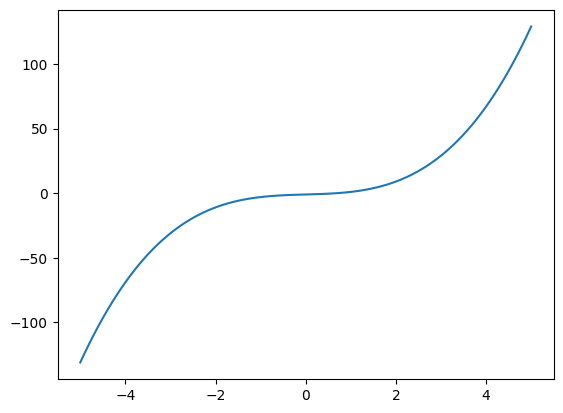

In [106]:
# Método de Newton Raphson

import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 + x - 1

def df(x):
    return 3*x**2 + 1

def newton_raphson(f,df,x0,N,tol):

    print(f"{'n':<{3}}{'x0':<{15}}{'f(x0)':<{15}}{'error':<{10}}")

    for i in range(N):

        r = x0 - (f(x0)/df(x0))

        error = abs(r - x0)

        print(f"{i+1:<{3}}{x0:<{15}.10f}{f(x0):<{15}.10f}{error:<{10}e}")

        if error < tol:
            return r, error 
        x0 = r

    print('No se pudo aproximar la raiz con la precisión deseada')
    return r, error

x = np.linspace(-5,5,100)

raiz, error = newton_raphson(f,df,-2,10,1e-6)

print(f'La raiz aproximada es {raiz} y su error es de {error}')

plt.plot(x, f(x))
plt.show()
    
